# Detection of Male and Female Eyes from image Dataset

## Using CNN

In [3]:
! pip install keras_preprocessing

In [4]:
! pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 784.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 107.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [5]:
# Import the required modules
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(



# Use Dataset from https://www.kaggle.com/datasets/pavelbiz/eyes-rtte

### This Dataset contains ~11K images of human eye photographs separated into two directories
#### Complete this notebook to demonstrates training and testing a simple keras binary classification CNN

In [6]:
! pip install kaggle

In [7]:
! kaggle datasets download pavelbiz/eyes-rtte

Dataset URL: https://www.kaggle.com/datasets/pavelbiz/eyes-rtte
License(s): copyright-authors
100% 40.4M/40.4M [00:00<00:00, 95.1MB/s]



In [8]:
!mkdir /content/eyes_dataset2
! mkdir /content/train_eye_dataset2

In [9]:
! unzip /content/eyes-rtte.zip -d /content/eyes_dataset2

Streaming output truncated to the last 5000 lines.
  inflating: /content/eyes_dataset2/maleeyes/2430.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2431.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2432.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2433.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2434.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2435.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2436.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2437.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2438.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2439.jpg  
  inflating: /content/eyes_dataset2/maleeyes/244.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2440.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2441.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2442.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2443.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2444.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2445.jpg 

In [10]:
BASIS_DIR = '/content/eyes_dataset2'
CLASSES = ["femaleeyes",  "maleeyes"]

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range = 0.2,
    zoom_range = 0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode = 'nearest',

    #split dataset to training(80%) and validation(20%):
    validation_split=0.2
)

In [12]:
train_data = train_datagen.flow_from_directory(
    directory=BASIS_DIR,
    target_size=(299, 299),
    batch_size=32,
    shuffle=True,
    class_mode='binary',
    subset='training',
    classes=CLASSES
    )

Found 9221 images belonging to 2 classes.


In [13]:
val_data = train_datagen.flow_from_directory(
    directory=BASIS_DIR,
    target_size=(299, 299),
    batch_size=32,
    shuffle=True,
    class_mode='binary',
    subset='validation',
    classes=CLASSES
    )

Found 2304 images belonging to 2 classes.


In [14]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(299, 299, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 297, 297, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,297,057 (16.39 MB)

 Trainable params: 4,297,057 (16.39 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# (filter_height*filter_width*number_of_channels+1)*number_of_filters
(3*3*32+1)*32

9248

In [17]:
# Compiling model with 'adam' optimizer loss function 'binary_crossentropy'
model.compile(loss='binary_crossentropy',
              optimizer=tf.optimizers.Adam(),
              metrics=['accuracy']
             )

In [20]:
# Training process:
number_epochs = 10
# You can change number_epochs above. But the bigger the value, the more time it takes for training
history = model.fit(train_data, epochs=number_epochs,
                    validation_data=val_data, verbose=2)

Epoch 1/10
289/289 - 507s - 2s/step - accuracy: 0.6937 - loss: 0.5913 - val_accuracy: 0.6975 - val_loss: 0.5765
Epoch 2/10
289/289 - 507s - 2s/step - accuracy: 0.7151 - loss: 0.5579 - val_accuracy: 0.7335 - val_loss: 0.5331
Epoch 3/10
289/289 - 511s - 2s/step - accuracy: 0.7441 - loss: 0.5188 - val_accuracy: 0.7465 - val_loss: 0.5077
Epoch 4/10
289/289 - 510s - 2s/step - accuracy: 0.7665 - loss: 0.4827 - val_accuracy: 0.7765 - val_loss: 0.4659
Epoch 5/10
289/289 - 510s - 2s/step - accuracy: 0.7898 - loss: 0.4517 - val_accuracy: 0.7904 - val_loss: 0.4581
Epoch 6/10
289/289 - 509s - 2s/step - accuracy: 0.7988 - loss: 0.4342 - val_accuracy: 0.7908 - val_loss: 0.4460
Epoch 7/10
289/289 - 512s - 2s/step - accuracy: 0.8101 - loss: 0.4175 - val_accuracy: 0.7804 - val_loss: 0.4754
Epoch 8/10
289/289 - 509s - 2s/step - accuracy: 0.8164 - loss: 0.4037 - val_accuracy: 0.8220 - val_loss: 0.4053
Epoch 9/10
289/289 - 509s - 2s/step - accuracy: 0.8344 - loss: 0.3727 - val_accuracy: 0.8329 - val_loss:

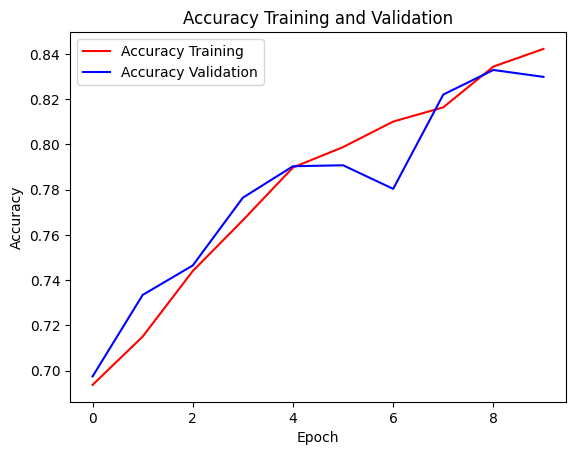

In [21]:
# Plotting training accuracy and validation accuracy
plt.plot(history.history['accuracy'], 'r', label='Accuracy Training')
plt.plot(history.history['val_accuracy'], 'b', label='Accuracy Validation')
plt.title('Accuracy Training and Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc=0)
plt.show()

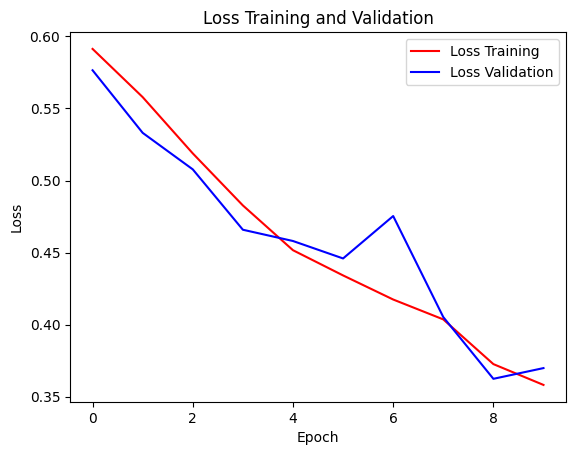

In [22]:
# Plotting training loss and validation loss
plt.plot(history.history['loss'], 'r', label='Loss Training')
plt.plot(history.history['val_loss'], 'b', label='Loss Validation')
plt.title('Loss Training and Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc=0)
plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras.models import save_model
# Save the compiled model to an H5 file
save_model(model, 'model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
female eyes


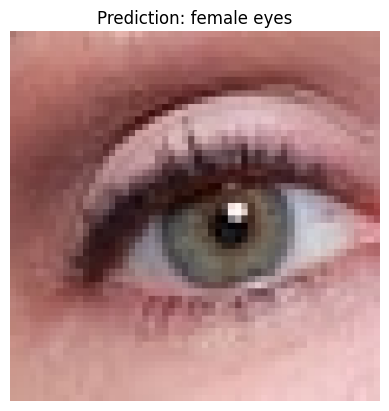

In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Assuming you have a pre-trained model saved as 'your_model.h5'
model = load_model('model.keras')

path = "/content/eyes_dataset2/femaleeyes/1002.jpg"
img = image.load_img(path, target_size=(299, 299))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

result = model.predict(img_array)

# Assuming your model output has two classes (COVID and Normal)
threshold = 0.5
prediction = "male Eyes" if result[0][0] > threshold else "female eyes"
print(prediction)

# Display the image
plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.axis('off')  # Hide the axes
plt.show()
